# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## Preparando os dados

Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

In [1]:
!pip install icrawler

In [2]:
import os
import shutil
import random
from icrawler.builtin import GoogleImageCrawler, BingImageCrawler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, utils
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import copy
from PIL import Image
import glob

### Adquirindo as Imagens

Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

In [3]:
def download_images(keyword, folder, n_total=100):
    os.makedirs(folder, exist_ok=True)
    downloaded = len(os.listdir(folder))
    remaining = n_total - downloaded

    while downloaded < n_total:
        crawler = BingImageCrawler(storage={'root_dir': folder})
        crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
        downloaded = len(os.listdir(folder))
        remaining = n_total - downloaded
        print(f"Downloaded {downloaded}/{n_total}")

    print("Download complete!")

In [4]:
search_terms = {
    "minecraft": "minecraft landscape", # nome da classe: termo que será usado na busca
    "real life": "landscape"
}

for label, term in search_terms.items():
    download_images(term, f"data/landscapes/{label}", n_total=100)

ERROR:downloader:Response status code 403, file https://coolwallpapers.me/th700/2861882-minecraft-render-screenshots-lake___landscape-nature-wallpapers.jpg
ERROR:downloader:Exception caught when downloading file https://cdn.webtekno.com/media/cache/content_detail_v2/article/101030/minecraft-server-kurulumu-nasil-yapilir-1603297243.jpg, error: HTTPSConnectionPool(host='cdn.webtekno.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://cdn.webtekno.com/media/cache/content_detail_v2/article/101030/minecraft-server-kurulumu-nasil-yapilir-1603297243.jpg, error: HTTPSConnectionPool(host='cdn.webtekno.com', port=443): Read timed out. (read timeout=5), remaining retry times: 1
ERROR:downloader:Exception caught when downloading file https://cdn.webtekno.com/media/cache/content_detail_v2/article/101030/minecraft-server-kurulumu-nasil-yapilir-1603297243.jpg, error: HTTPSConnectionPool(host='cdn.webtekno.com', po

Downloaded 7/100


ERROR:downloader:Response status code 403, file https://coolwallpapers.me/th700/2861882-minecraft-render-screenshots-lake___landscape-nature-wallpapers.jpg
ERROR:downloader:Exception caught when downloading file https://cdn.webtekno.com/media/cache/content_detail_v2/article/101030/minecraft-server-kurulumu-nasil-yapilir-1603297243.jpg, error: HTTPSConnectionPool(host='cdn.webtekno.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://cdn.webtekno.com/media/cache/content_detail_v2/article/101030/minecraft-server-kurulumu-nasil-yapilir-1603297243.jpg, error: HTTPSConnectionPool(host='cdn.webtekno.com', port=443): Read timed out. (read timeout=5), remaining retry times: 1
ERROR:downloader:Exception caught when downloading file https://cdn.webtekno.com/media/cache/content_detail_v2/article/101030/minecraft-server-kurulumu-nasil-yapilir-1603297243.jpg, error: HTTPSConnectionPool(host='cdn.webtekno.com', po

Downloaded 14/100


ERROR:downloader:Response status code 403, file https://coolwallpapers.me/th700/2861882-minecraft-render-screenshots-lake___landscape-nature-wallpapers.jpg
ERROR:downloader:Exception caught when downloading file https://cdn.webtekno.com/media/cache/content_detail_v2/article/101030/minecraft-server-kurulumu-nasil-yapilir-1603297243.jpg, error: HTTPSConnectionPool(host='cdn.webtekno.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://cdn.webtekno.com/media/cache/content_detail_v2/article/101030/minecraft-server-kurulumu-nasil-yapilir-1603297243.jpg, error: HTTPSConnectionPool(host='cdn.webtekno.com', port=443): Read timed out. (read timeout=5), remaining retry times: 1
ERROR:downloader:Exception caught when downloading file https://cdn.webtekno.com/media/cache/content_detail_v2/article/101030/minecraft-server-kurulumu-nasil-yapilir-1603297243.jpg, error: HTTPSConnectionPool(host='cdn.webtekno.com', po

...

Downloaded 58/100


ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/026/481/532/large_2x/serenity-and-peace-with-this-breathtaking-4k-wallpaper-depicting-a-tranquil-natural-landscape-free-photo.jpg
ERROR:downloader:Response status code 403, file https://photographylife.com/wp-content/uploads/2017/01/Landscape-photography-example.jpg
ERROR:downloader:Response status code 403, file https://www.creativefabrica.com/wp-content/uploads/2023/04/17/Nature-Landscape-Background-Graphics-67486896-1.jpg


Downloaded 87/100


ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/026/481/532/large_2x/serenity-and-peace-with-this-breathtaking-4k-wallpaper-depicting-a-tranquil-natural-landscape-free-photo.jpg
ERROR:downloader:Response status code 403, file https://photographylife.com/wp-content/uploads/2017/01/Landscape-photography-example.jpg


Downloaded 100/100
Download complete!


### Treinamento e Validação

Dividiremos as imagens baixadas nas pastas `train` e `val`. Defina uma porcentagem.

In [5]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

In [6]:
split_train_val("data/landscapes")

minecraft: 80 train, 20 val
real life: 80 train, 20 val


## Dataset

Implemente um Dataset PyTorch que carregue as imagens baixadas com suas respectivas classes. Aplique data augmentation e carregue em batches.

In [7]:
class LandscapesDataset(Dataset):
  def __init__(self, root_dir, transform=None):
    self.root_dir = root_dir
    self.transform = transform
    self.class_names = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

    self.data = []
    for class_name in self.class_names:
      class_dir = os.path.join(self.root_dir, class_name)
      for filename in os.listdir(class_dir):
          if filename.endswith(('.png', '.jpg', '.jpeg')):
              path = os.path.join(class_dir, filename)
              item = (path, self.class_to_idx[class_name])
              self.data.append(item)

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    img_path, label = self.data[idx]
    image = Image.open(img_path).convert("RGB")
    if self.transform:
        image = self.transform(image)
    return image, label

In [8]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'data/landscapes_split'

# Criando instâncias de Dataset
train_dataset = LandscapesDataset(os.path.join(data_dir, 'train'), data_transforms['train'])
val_dataset = LandscapesDataset(os.path.join(data_dir, 'val'), data_transforms['val'])

# Criando instâncias de DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=4)

# Obtendo informações
class_names = train_dataset.class_names
train_size = len(train_dataset)
val_size = len(val_dataset)

print(f"Classes: {class_names}")
print(f"Tamanho do dataset de treino: {train_size}")
print(f"Tamanho do dataset de validação: {val_size}")

Classes: ['minecraft', 'real life']
Tamanho do dataset de treino: 160
Tamanho do dataset de validação: 40


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


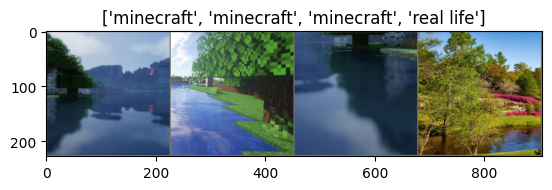

In [9]:
def imshow(inp, title=None):
    """Função para exibir um tensor de imagem."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Obtém um batch de dados de treino
inputs, classes = next(iter(train_dataloader))

# Cria uma grade a partir do batch
out = utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

## Definição do Modelo

Defina aqui o modelo que será utilizado, sendo implementação própria ou um modelo pré-treinado.

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = SimpleCNN().to(device)

## Treinamento

Defina a função de custo e o otimizador do modelo. Em seguida, implemente o código de treinamento e treine-o. Ao final, exiba as curvas de treinamento e validação para a loss e a acurácia.

In [12]:
from tqdm.notebook import tqdm

def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=25):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')

        for phase, loader in [('train', train_loader), ('val', val_loader)]:
            model.train(phase == 'train')
            running_loss, running_corrects = 0.0, 0
            size = len(loader.dataset)

            loop = tqdm(loader, desc=f'{phase.capitalize()}')
            for inputs, labels in loop:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / size
            epoch_acc = running_corrects.double() / size
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
    return history


def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history['train_acc'], label='Train Accuracy')
    ax1.plot(history['val_acc'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history['train_loss'], label='Train Loss')
    ax2.plot(history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.show()

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

history = train_model(
    model, criterion, optimizer, train_dataloader, val_dataloader, num_epochs=25
)


Epoch 1/25


Train:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 3.0548 Acc: 0.6125


Val:   0%|          | 0/10 [00:00<?, ?it/s]

Val Loss: 0.4305 Acc: 0.8500

Epoch 2/25


...

Val Loss: 0.1340 Acc: 0.9750

Epoch 25/25


Train:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 0.3060 Acc: 0.8625


Val:   0%|          | 0/10 [00:00<?, ?it/s]

Val Loss: 0.1460 Acc: 0.9500


## Inferência

Calcule algumas métricas como acurácia, matriz de confusão, etc. Em seguida, teste o modelo em novas imagens das classes correspondentes mas de outras fontes (outro buscador, fotos próprias, etc).

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [15]:
# Avaliação no conjunto de teste
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in val_dataloader:
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\nAcurácia: {acc:.2f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Acurácia: 0.95


In [16]:
# Relatório de classificação
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

   minecraft       1.00      0.90      0.95        20
   real life       0.91      1.00      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



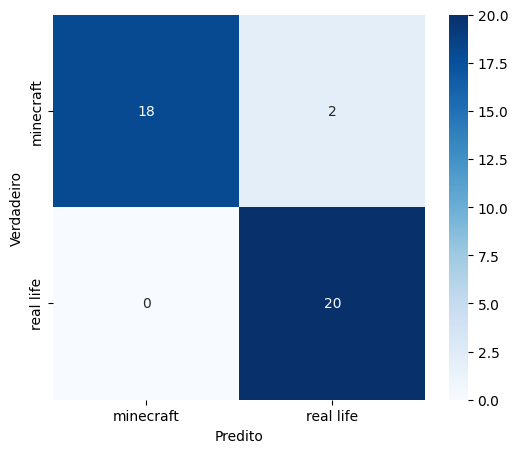

In [17]:
# Matriz de confusão
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.show()

In [21]:
def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")

    imshow(data_transforms['val'](img))

    img_transformed = data_transforms['val'](img).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        outputs = model(img_transformed)
        _, pred = torch.max(outputs, 1)

    return class_names[pred.item()]

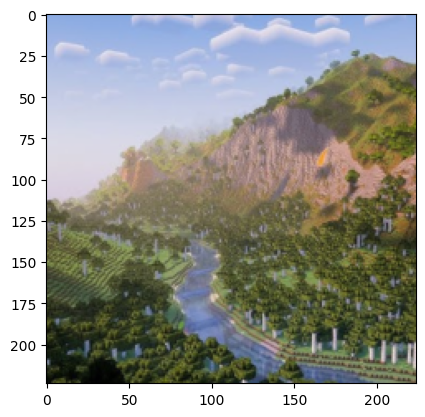

'minecraft'

In [23]:
predict_image('minecraft.jpg')

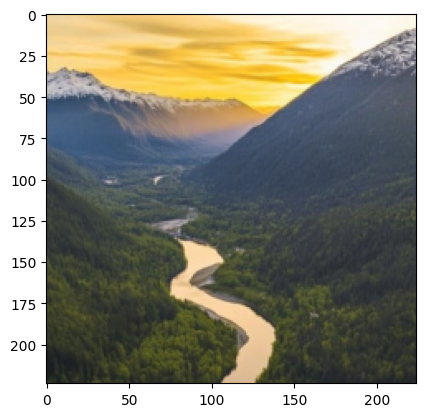

'real life'

In [24]:
predict_image('real.jpg')